In [1]:
# Cell 1 - Imports
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

train = pd.read_csv('cs-training.csv')
test = pd.read_csv('cs-test.csv')

print(f"Train size: {train.shape}")
print(f"Test size: {test.shape}")

Train size: (150000, 12)
Test size: (101503, 12)


In [2]:
print(train.head())

   Unnamed: 0  SeriousDlqin2yrs  RevolvingUtilizationOfUnsecuredLines  age  \
0           1                 1                              0.766127   45   
1           2                 0                              0.957151   40   
2           3                 0                              0.658180   38   
3           4                 0                              0.233810   30   
4           5                 0                              0.907239   49   

   NumberOfTime30-59DaysPastDueNotWorse  DebtRatio  MonthlyIncome  \
0                                     2   0.802982         9120.0   
1                                     0   0.121876         2600.0   
2                                     1   0.085113         3042.0   
3                                     0   0.036050         3300.0   
4                                     1   0.024926        63588.0   

   NumberOfOpenCreditLinesAndLoans  NumberOfTimes90DaysLate  \
0                               13                   

In [3]:
print(list(train.columns))

['Unnamed: 0', 'SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']


In [4]:
# Cell 2 - Rename columns

train = train.rename(columns={
    'SeriousDlqin2yrs'                     : 'Default',
    'RevolvingUtilizationOfUnsecuredLines'  : 'CreditLineUsage',
    'age'                                   : 'Age',
    'NumberOfTime30-59DaysPastDueNotWorse'  : 'Late30to59Days',
    'DebtRatio'                             : 'DebtRatio',
    'MonthlyIncome'                         : 'MonthlyIncome',
    'NumberOfOpenCreditLinesAndLoans'       : 'OpenCreditLines',
    'NumberOfTimes90DaysLate'               : 'Late90Days',
    'NumberRealEstateLoansOrLines'          : 'RealEstateLoans',
    'NumberOfTime60-89DaysPastDueNotWorse'  : 'Late60to89Days',
    'NumberOfDependents'                    : 'Dependents'
})

# Drop useless index column
train = train.drop(columns=['Unnamed: 0'])

print("Columns after renaming:")
print(train.columns.tolist())

Columns after renaming:
['Default', 'CreditLineUsage', 'Age', 'Late30to59Days', 'DebtRatio', 'MonthlyIncome', 'OpenCreditLines', 'Late90Days', 'RealEstateLoans', 'Late60to89Days', 'Dependents']


In [5]:
# Cell 3 — Raw Dataset Overview (BEFORE cleaning)
print("=== Shape ===")
print(train.shape)

print("\n=== Data Types ===")
print(train.dtypes)

print("\n=== Basic Statistics ===")
print(train.describe())

print("\n=== Missing Values (%) ===")
missing = (train.isnull().sum() / len(train) * 100).round(2)
print(missing[missing > 0].sort_values(ascending=False))

print("\n=== Class Distribution ===")
print(train['Default'].value_counts())
print(train['Default'].value_counts(normalize=True).round(3) * 100)

=== Shape ===
(150000, 11)

=== Data Types ===
Default              int64
CreditLineUsage    float64
Age                  int64
Late30to59Days       int64
DebtRatio          float64
MonthlyIncome      float64
OpenCreditLines      int64
Late90Days           int64
RealEstateLoans      int64
Late60to89Days       int64
Dependents         float64
dtype: object

=== Basic Statistics ===
             Default  CreditLineUsage            Age  Late30to59Days  \
count  150000.000000    150000.000000  150000.000000   150000.000000   
mean        0.066840         6.048438      52.295207        0.421033   
std         0.249746       249.755371      14.771866        4.192781   
min         0.000000         0.000000       0.000000        0.000000   
25%         0.000000         0.029867      41.000000        0.000000   
50%         0.000000         0.154181      52.000000        0.000000   
75%         0.000000         0.559046      63.000000        0.000000   
max         1.000000     50708.000000   

In [6]:
# Cell 4 — Handle Missing Values

# --- MonthlyIncome (19.82% missing) ---
# MNAR: Missing Not At Random
# People with irregular income (freelancers, unemployed, self-employed)
# are more likely to leave this blank — not a random mistake.
# Strategy: Indicator + Constant (Option 3)
#   Step 1: Create a binary flag to preserve the "missingness" information
#   Step 2: Fill with 0 as a neutral placeholder
# The model will learn independently whether missing income is a risk signal.

train['MonthlyIncome_Was_Missing'] = train['MonthlyIncome'].isnull().astype(int)
train['MonthlyIncome'] = train['MonthlyIncome'].fillna(0)

print("MonthlyIncome — missing values handled")
print(f"People with missing income flagged: {train['MonthlyIncome_Was_Missing'].sum()}")

# --- Dependents (2.62% missing) ---
# Much simpler case — only 2.62% missing.
# Most people with no dependents might have just skipped this field.
# Safe to fill with Median (0 — since 75% of people have 0 or 1 dependents).
train['Dependents'] = train['Dependents'].fillna(train['Dependents'].median())
train['Dependents'] = train['Dependents'].astype(int)

print("\nDependents — missing values handled")

# --- Verify ---
print("\n=== Missing Values Remaining ===")
total = train.isnull().sum().sum()
print(f"Total: {total}")
print("(0 = clean ✓)" if total == 0 else "Still have missing values!")

print(f"\nNew column added: MonthlyIncome_Was_Missing")
print(f"Train shape now: {train.shape}")

MonthlyIncome — missing values handled
People with missing income flagged: 29731

Dependents — missing values handled

=== Missing Values Remaining ===
Total: 0
(0 = clean ✓)

New column added: MonthlyIncome_Was_Missing
Train shape now: (150000, 12)


In [7]:
# Cell 5 — Fix Invalid Age
# One person has age = 0 — impossible for a loan applicant.
# Clear data entry error.
# Since it's only 1 row, we replace it with the median age
# instead of dropping it — preserving the full 150,000 rows.

age_median = train[train['Age'] > 0]['Age'].median()
train['Age'] = train['Age'].replace(0, age_median)

print(f"Age = 0 replaced with median age: {age_median}")
print(f"Minimum age now: {train['Age'].min()}")
print(f"Dataset size: {len(train)} rows (unchanged)")

Age = 0 replaced with median age: 52.0
Minimum age now: 21
Dataset size: 150000 rows (unchanged)


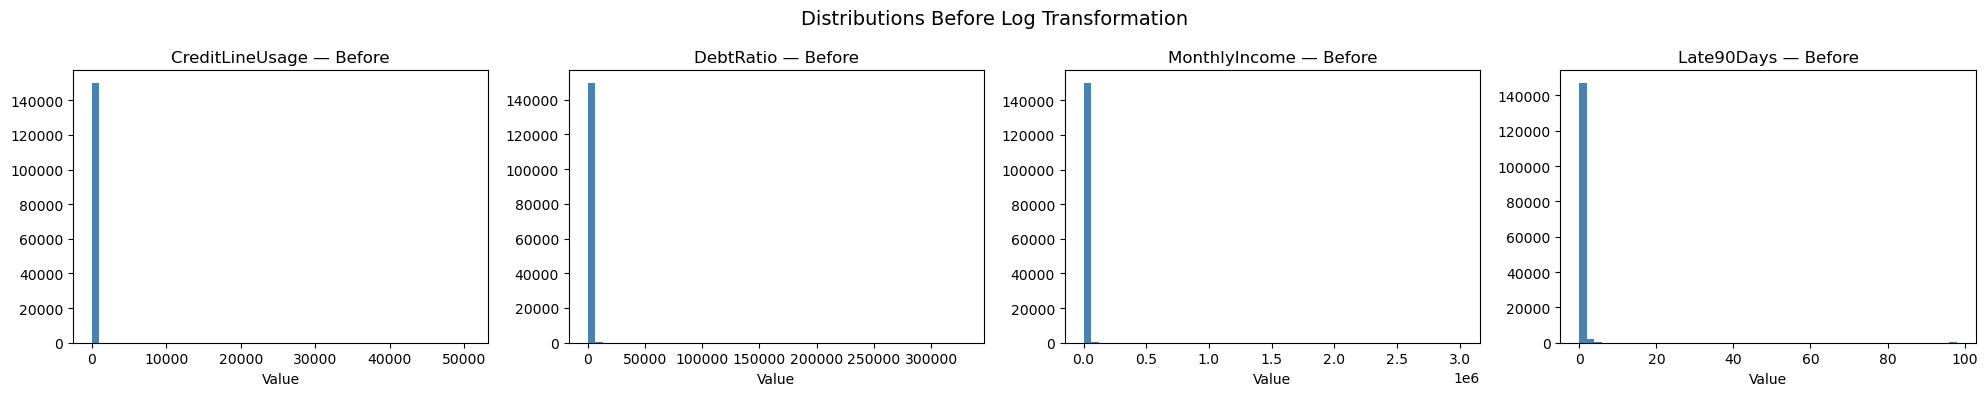

In [8]:
# Cell 6 — Outlier Visualization (Before Log Transformation)

cols_to_plot = ['CreditLineUsage', 'DebtRatio', 
                'MonthlyIncome', 'Late90Days']

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for i, col in enumerate(cols_to_plot):
    axes[i].hist(train[col], bins=50, color='steelblue')
    axes[i].set_title(f'{col} — Before')
    axes[i].set_xlabel('Value')

plt.suptitle('Distributions Before Log Transformation', fontsize=14)
plt.tight_layout()
plt.show()

In [9]:
# Cell 7 — Log Transformation (Outlier Treatment)
# These columns contain extreme values that would dominate the model.
# log1p = log(1 + value) — safe for zero values (log(0) is undefined)

cols_to_transform = ['CreditLineUsage', 'DebtRatio', 
                     'MonthlyIncome', 'Late90Days',
                     'Late30to59Days', 'Late60to89Days',
                     'Dependents', 'OpenCreditLines', 
                     'RealEstateLoans']

for col in cols_to_transform:
    train[col] = np.log1p(train[col])

print("Log transformation applied to:")
for col in cols_to_transform:
    print(f"  {col}: min={train[col].min():.3f}, max={train[col].max():.3f}")

Log transformation applied to:
  CreditLineUsage: min=0.000, max=10.834
  DebtRatio: min=0.000, max=12.706
  MonthlyIncome: min=0.000, max=14.917
  Late90Days: min=0.000, max=4.595
  Late30to59Days: min=0.000, max=4.595
  Late60to89Days: min=0.000, max=4.595
  Dependents: min=0.000, max=3.045
  OpenCreditLines: min=0.000, max=4.078
  RealEstateLoans: min=0.000, max=4.007


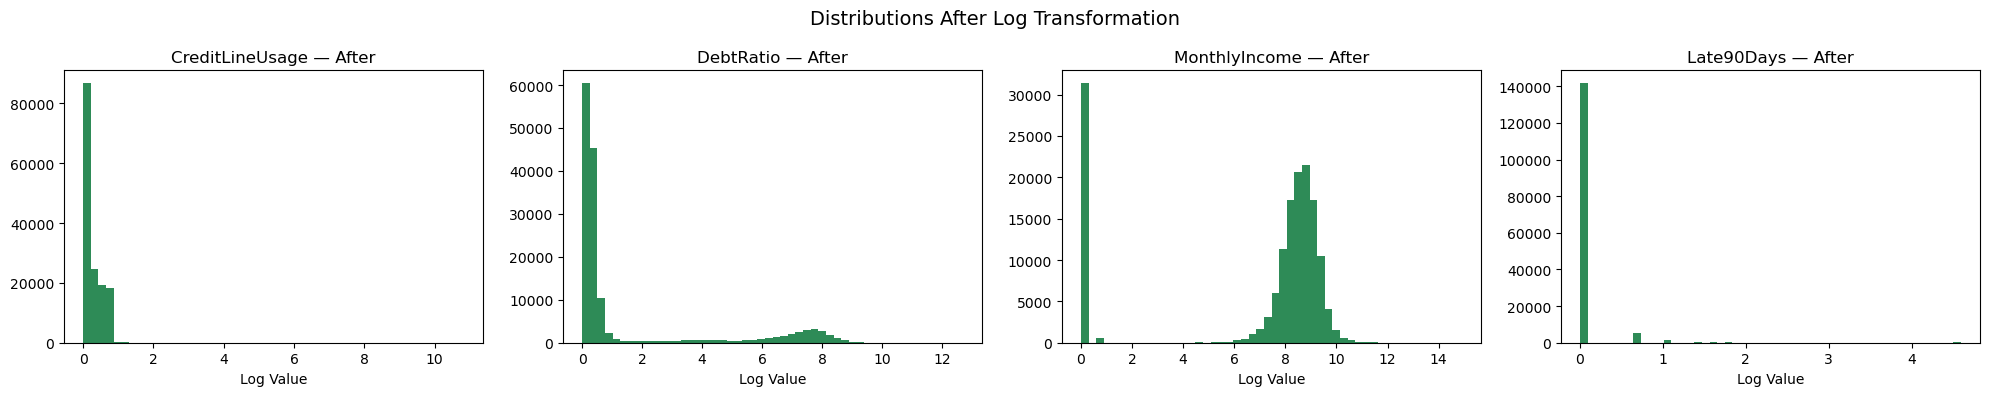

In [10]:
# Cell 8 — Outlier Visualization (After Log Transformation)

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for i, col in enumerate(cols_to_plot):
    axes[i].hist(train[col], bins=50, color='seagreen')
    axes[i].set_title(f'{col} — After')
    axes[i].set_xlabel('Log Value')

plt.suptitle('Distributions After Log Transformation', fontsize=14)
plt.tight_layout()
plt.show()

In [11]:
# Cell 9 — Undersampling (Fix Class Imbalance)
# Current distribution: 93.3% (no default) vs 6.7% (default)
# If we train on this, the model will just predict "no default" for everyone.
# Solution: Keep ALL defaulters, randomly reduce non-defaulters to 30,000.
# Result: ~75% / 25% split — balanced enough to learn from.

# Step 1 — Separate the two classes
defaulters     = train[train['Default'] == 1]   # 10,026 rows
non_defaulters = train[train['Default'] == 0]   # 139,974 rows

print(f"Defaulters: {len(defaulters)}")
print(f"Non-defaulters before: {len(non_defaulters)}")

# Step 2 — Randomly keep 30,000 non-defaulters
non_defaulters_reduced = non_defaulters.sample(n=30000, random_state=42)

# Step 3 — Combine back together
train_balanced = pd.concat([defaulters, non_defaulters_reduced])

# Step 4 — Shuffle so defaulters aren't all at the top
train_balanced = train_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# Step 5 — Verify
print(f"\nAfter undersampling:")
print(train_balanced['Default'].value_counts())
print(train_balanced['Default'].value_counts(normalize=True).round(3) * 100)
print(f"\nFinal shape: {train_balanced.shape}")

Defaulters: 10026
Non-defaulters before: 139974

After undersampling:
Default
0    30000
1    10026
Name: count, dtype: int64
Default
0    75.0
1    25.0
Name: proportion, dtype: float64

Final shape: (40026, 12)


In [12]:
# Cell 10 — MinMax Scaling (Normalization)

# WHY DO WE SCALE?
# After log transformation, columns still have different ranges:
#   MonthlyIncome: 0 to 14.917
#   Late90Days:    0 to 4.595
#   Age:           21 to 109
# A neural network pays more attention to bigger numbers.
# Scaling brings everything to the same 0-1 range so the model
# evaluates each feature fairly.

# We do NOT scale:
#   Default              → target column, never touch it
#   MonthlyIncome_Was_Missing → already 0 or 1

cols_to_scale = ['CreditLineUsage', 'Age', 'Late30to59Days',
                 'DebtRatio', 'MonthlyIncome', 'OpenCreditLines',
                 'Late90Days', 'RealEstateLoans', 'Late60to89Days',
                 'Dependents']

# Save min and max from balanced training data — needed later for FastAPI
scale_params = {}

for col in cols_to_scale:
    col_min = train_balanced[col].min()
    col_max = train_balanced[col].max()
    scale_params[col] = {'min': col_min, 'max': col_max}
    
    train_balanced[col] = (train_balanced[col] - col_min) / (col_max - col_min)

print("Scaling applied to:", cols_to_scale)
print()
print("=== Value Ranges After Scaling ===")
print(train_balanced[cols_to_scale].describe().loc[['min', 'max']].round(3))

Scaling applied to: ['CreditLineUsage', 'Age', 'Late30to59Days', 'DebtRatio', 'MonthlyIncome', 'OpenCreditLines', 'Late90Days', 'RealEstateLoans', 'Late60to89Days', 'Dependents']

=== Value Ranges After Scaling ===
     CreditLineUsage  Age  Late30to59Days  DebtRatio  MonthlyIncome  \
min              0.0  0.0             0.0        0.0            0.0   
max              1.0  1.0             1.0        1.0            1.0   

     OpenCreditLines  Late90Days  RealEstateLoans  Late60to89Days  Dependents  
min              0.0         0.0              0.0             0.0         0.0  
max              1.0         1.0              1.0             1.0         1.0  


In [13]:
# Cell 11 — Final Verification (Clean Dataset)
print("=== Final Shape ===")
print(train_balanced.shape)

print("\n=== Missing Values ===")
total = train_balanced.isnull().sum().sum()
print(f"Total: {total} ✓" if total == 0 else f"Still missing: {total}")

print("\n=== Class Distribution ===")
print(train_balanced['Default'].value_counts())
print(train_balanced['Default'].value_counts(normalize=True).round(3) * 100)

print("\n=== First 5 Rows (Clean Dataset) ===")
print(train_balanced.head())

=== Final Shape ===
(40026, 12)

=== Missing Values ===
Total: 0 ✓

=== Class Distribution ===
Default
0    30000
1    10026
Name: count, dtype: int64
Default
0    75.0
1    25.0
Name: proportion, dtype: float64

=== First 5 Rows (Clean Dataset) ===
   Default  CreditLineUsage       Age  Late30to59Days  DebtRatio  \
0        1         0.037313  0.125000        0.000000   0.018398   
1        0         0.035268  0.250000        0.000000   0.574263   
2        0         0.000897  0.261364        0.150844   0.017817   
3        0         0.006968  0.397727        0.000000   0.020686   
4        1         0.068810  0.022727        0.000000   0.014729   

   MonthlyIncome  OpenCreditLines  Late90Days  RealEstateLoans  \
0       0.608299         0.567077         0.0         0.000000   
1       0.000000         0.590550         0.0         0.000000   
2       0.663665         0.590550         0.0         0.323008   
3       0.691852         0.649943         0.0         0.323008   
4       0.5

In [14]:
# Cell 12 — Save Clean Dataset
train_balanced.to_csv('clean_dataset.csv', index=False)
print("Clean dataset saved as: clean_dataset.csv")
print(f"Shape: {train_balanced.shape}")

Clean dataset saved as: clean_dataset.csv
Shape: (40026, 12)


In [15]:
# Cell 13 — Save Scale Parameters
import json
with open('scale_params.json', 'w') as f:
    json.dump(scale_params, f)
print("Scale parameters saved as: scale_params.json")
print(json.dumps(scale_params, indent=2))

Scale parameters saved as: scale_params.json
{
  "CreditLineUsage": {
    "min": 0.0,
    "max": 10.007802521800768
  },
  "Age": {
    "min": 21,
    "max": 109
  },
  "Late30to59Days": {
    "min": 0.0,
    "max": 4.59511985013459
  },
  "DebtRatio": {
    "min": 0.0,
    "max": 12.634609541206094
  },
  "MonthlyIncome": {
    "min": 0.0,
    "max": 13.635236104423946
  },
  "OpenCreditLines": {
    "min": 0.0,
    "max": 4.060443010546419
  },
  "Late90Days": {
    "min": 0.0,
    "max": 4.59511985013459
  },
  "RealEstateLoans": {
    "min": 0.0,
    "max": 3.4011973816621555
  },
  "Late60to89Days": {
    "min": 0.0,
    "max": 4.59511985013459
  },
  "Dependents": {
    "min": 0.0,
    "max": 2.3978952727983707
  }
}
